# Notebook 04 - Door Impact Sound (FEM)

Author: Stellars Henson<br>
Approach: the metallic **clang** of the elevator door when the body strikes it, as heard by a microphone in the room. The door is the only source in this notebook - the body and the air it pushes are notebook 03.

The modelling lives in the `henryk_simulations.corridor.doorfem` library; this notebook is a thin client over its staged functions.

## Model decisions

- **The actual door box, tessellated.** The ZREMB DT37/1 leaf is a welded steel box - two skins tied by a perimeter frame, with a tall narrow wired-glass vision window. The steel volume is voxelised into a tetrahedral solid the same way the torso was.
- **3D finite-element model.** scikit-fem assembles the box's 3D linear-elastic stiffness and mass; an eigensolve gives the leaf's flexural modes - what makes a stiff steel door clang rather than boom.
- **The body strikes the front skin.** The body-door contact force - notebook 02's impact, grained by notebook 03's surface texture - excites the modes; modal damping settles the ring.
- **The room-side skin radiates.** The leaf is set in the wall, so its room-side skin is a baffled radiator. Below the steel coincidence frequency the modes radiate sub-critically, with efficiency below one.


In [1]:
%load_ext autoreload
%autoreload 2

# Imports
from __future__ import annotations

import dataclasses
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import wavfile

from rich.console import Console
from rich.panel import Panel
from rich.table import Table

# Project library - the FEM door-sound modelling lives in the corridor submodule
from henryk_simulations.corridor.doorfem import (
    DoorFEMConfig,
    impact_response,
    radiate,
    solve_door_modes,
    solve_door_sound,
    voxelise_door,
)
from henryk_simulations.corridor.bodyfem import load_body_mesh, sound_levels

# the closing-velocity envelope is taken from notebook 01's kinematics
from henryk_simulations.corridor.choreography import ChoreographyConfig, solve_envelope
# the corridor reflections are applied as a post-processing filter
from henryk_simulations.corridor.reverb import (
    CorridorReverbConfig,
    apply_corridor_reverb,
    corridor_impulse_response,
)

console = Console()
sns.set_theme(style="whitegrid", context="notebook")

2026-05-18 14:57:09.572 | INFO     | henryk_simulations.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/private/henryk/henryk-simulations


In [2]:
SEED = 42
np.random.seed(SEED)


## Configuration

`DoorFEMConfig` is the single configuration object for this notebook - the door box geometry (panel size, leaf depth, skin thickness, the welded frame, the window cutout), the steel material, the FEM voxel size and mode count, the modal damping, the impact, and the acoustics. Every section below reads from it.


In [3]:
CFG = DoorFEMConfig()
FIG_DIR = Path("..") / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

cfg_tbl = Table(show_header=False, box=None, padding=(0, 2))
cfg_tbl.add_column("field", style="grey70")
cfg_tbl.add_column("value")
for f in dataclasses.fields(CFG):
    cfg_tbl.add_row(f.name, f"[white]{getattr(CFG, f.name)}[/white]")
console.print(Panel(cfg_tbl, title="[bold medium_purple]DoorFEMConfig[/bold medium_purple]",
                    border_style="medium_purple"))

REVERB = CorridorReverbConfig()
rev_tbl = Table(show_header=False, box=None, padding=(0, 2))
rev_tbl.add_column("field", style="grey70")
rev_tbl.add_column("value")
for f in dataclasses.fields(REVERB):
    rev_tbl.add_row(f.name, f"[white]{getattr(REVERB, f.name)}[/white]")
console.print(Panel(rev_tbl, title="[bold medium_purple]CorridorReverbConfig[/bold medium_purple]",
                    border_style="medium_purple"))

╭───────────────────────────────────────────────── DoorFEMConfig ─────────────────────────────────────────────────╮
│   panel_width       1.0                                                                                         │
│   panel_height      2.0                                                                                         │
│   skin_thickness    0.002                                                                                       │
│   cavity_gap        0.025                                                                                       │
│   frame_width       0.04                                                                                        │
│   window_width      0.15                                                                                        │
│   window_height     1.2                                                                                         │
│   window_cx         0.5                                                                                         │
│   window_cy         1.1                                                                                         │
│   youngs_modulus    200000000000.0                                                                              │
│   poisson           0.3                                                                                         │
│   density           7850.0                                                                                      │
│   voxel_size        0.025                                                                                       │
│   n_modes           30                                                                                          │
│   modal_damping     0.02                                                                                        │
│   v_close           2.74                                                                                        │
│   strike_x          0.65                                                                                        │
│   strike_y          1.3                                                                                         │
│   air_rho           1.2                                                                                         │
│   air_c             343.0                                                                                       │
│   mic_distance      1.0                                                                                         │
│   sample_rate       44100                                                                                       │
│   t_max             0.6                                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── CorridorReverbConfig ──────────────────────────────────────────────╮
│   corridor_width     2.0                                                                                        │
│   corridor_length    10.0                                                                                       │
│   source_x           1.0                                                                                        │
│   source_y           1.0                                                                                        │
│   mic_x              1.0                                                                                        │
│   mic_y              2.0                                                                                        │
│   wall_reflection    0.85                                                                                       │
│   max_order          12                                                                                         │
│   air_c              343.0                                                                                      │
│   sample_rate        44100                                                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Scene

The body is thrown back-first into the elevator door. The figure superimposes the body silhouette on the door and marks where the impact lands - the strike point, in the upper-back region, where the contact force is applied to the steel leaf.


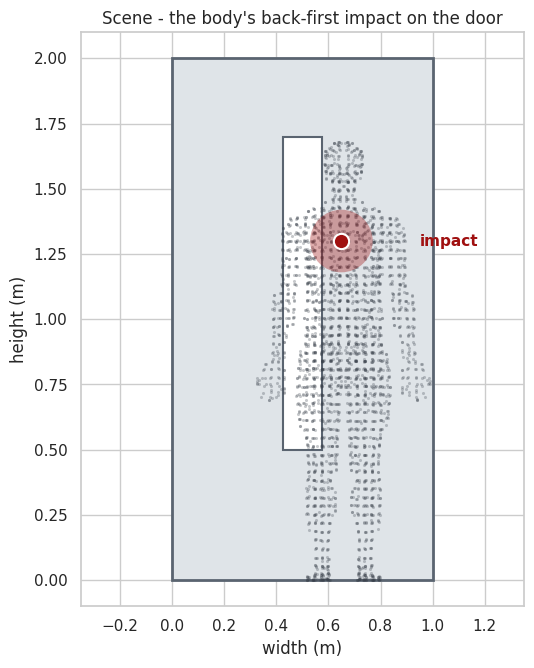

In [4]:
body_points, _ = load_body_mesh()
# project the body onto the door plane, scale to a 1.68 m stature, stand it
# on the floor and centre it on the strike point
bx = body_points[:, 0] - np.median(body_points[:, 0])
bz = body_points[:, 2] - body_points[:, 2].min()
scale = 1.68 / bz.max()
bx, bz = bx * scale + CFG.strike_x, bz * scale

fig, ax = plt.subplots(figsize=(5.5, 8.5))
ax.add_patch(plt.Rectangle((0, 0), CFG.panel_width, CFG.panel_height,
                           facecolor="#dfe4e8", edgecolor="#5a6470", lw=2.0))
wx0 = CFG.window_cx - CFG.window_width / 2
wy0 = CFG.window_cy - CFG.window_height / 2
ax.add_patch(plt.Rectangle((wx0, wy0), CFG.window_width, CFG.window_height,
                           facecolor="white", edgecolor="#5a6470", lw=1.5))
ax.scatter(bx, bz, s=5, color="#39404a", alpha=0.28, linewidths=0)
ax.add_patch(plt.Circle((CFG.strike_x, CFG.strike_y), 0.12,
                        facecolor="#a01010", alpha=0.35, edgecolor="none"))
ax.plot(CFG.strike_x, CFG.strike_y, "o", ms=11, mfc="#a01010", mec="white", mew=1.5)
ax.annotate("impact", (CFG.strike_x, CFG.strike_y),
            xytext=(CFG.strike_x + 0.30, CFG.strike_y), va="center",
            fontsize=11, color="#a01010", fontweight="bold")
ax.set_aspect("equal")
ax.set_xlim(-0.35, CFG.panel_width + 0.35)
ax.set_ylim(-0.1, CFG.panel_height + 0.1)
ax.set_xlabel("width (m)")
ax.set_ylabel("height (m)")
ax.set_title("Scene - the body's back-first impact on the door")
fig.tight_layout()
fig.savefig(FIG_DIR / "04-scene.png", dpi=140, bbox_inches="tight")
plt.show()


## The Steel Door Box

The ZREMB DT37/1 leaf is a welded box, not a flat sheet - and that is what makes it stiff. The wired-glass vision window is a tall narrow cutout. The steel volume is voxelised into a tetrahedral solid: three layers through the depth - front skin, hollow core, back skin - with the frame filling the core at the perimeter and around the window.


╭───────────────────────────────────────────── Tessellated door box ──────────────────────────────────────────────╮
│ voxel size 25 mm    nodes 12344    tetrahedra 39120    steel mass 143 kg                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

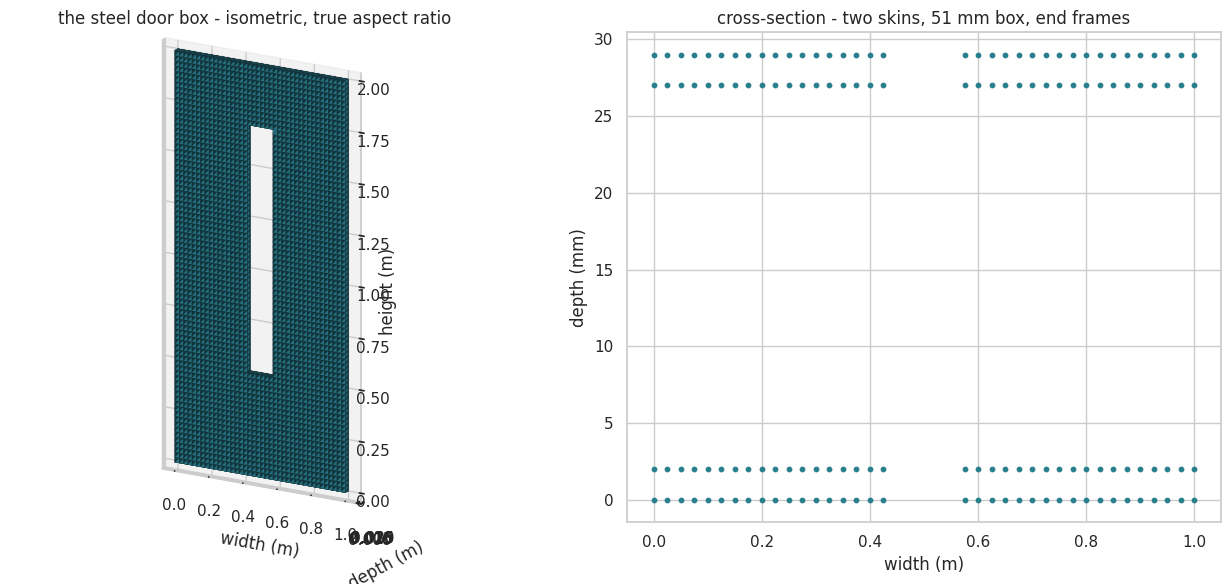

In [5]:
nodes, tets = voxelise_door(CFG)
steel_mass = CFG.density * abs(np.linalg.det(
    np.stack([nodes[tets[:, 1]] - nodes[tets[:, 0]],
              nodes[tets[:, 2]] - nodes[tets[:, 0]],
              nodes[tets[:, 3]] - nodes[tets[:, 0]]], axis=1)
)).sum() / 6.0

console.print(Panel(
    f"voxel size [white]{CFG.voxel_size * 1e3:.0f} mm[/white]    "
    f"nodes [white]{len(nodes)}[/white]    tetrahedra [white]{len(tets)}[/white]    "
    f"steel mass [white]{steel_mass:.0f} kg[/white]",
    title="[bold medium_purple]Tessellated door box[/bold medium_purple]",
    border_style="medium_purple"))

# boundary surface - the triangular faces shared by only one tetrahedron
faces = np.sort(np.vstack([
    tets[:, [0, 1, 2]], tets[:, [0, 1, 3]], tets[:, [0, 2, 3]], tets[:, [1, 2, 3]]
]), axis=1)
uniq, counts = np.unique(faces, axis=0, return_counts=True)
boundary = uniq[counts == 1]

fig = plt.figure(figsize=(13, 6))
ax = fig.add_subplot(1, 2, 1, projection="3d")
# render with the door's height as the vertical axis, so it stands upright
ax.plot_trisurf(nodes[:, 0], nodes[:, 2], nodes[:, 1], triangles=boundary,
                color="#2a7f8f", edgecolor="#16323a", linewidth=0.15)
ax.set_proj_type("ortho")  # isometric - orthographic, no perspective
ax.set_box_aspect((CFG.panel_width, CFG.leaf_depth, CFG.panel_height))  # true aspect
ax.view_init(elev=18, azim=-60)
ax.set_xlabel("width (m)")
ax.set_ylabel("depth (m)")
ax.set_zlabel("height (m)")
ax.set_title("the steel door box - isometric, true aspect ratio")

ax = fig.add_subplot(1, 2, 2)
mid = np.argmin(np.abs(np.unique(nodes[:, 1]) - CFG.panel_height / 2))
y_mid = np.unique(nodes[:, 1])[mid]
slab = np.isclose(nodes[:, 1], y_mid)
ax.scatter(nodes[slab, 0], nodes[slab, 2] * 1e3, s=10, color="#2a7f8f")
ax.set_xlabel("width (m)")
ax.set_ylabel("depth (mm)")
ax.set_title("cross-section - two skins, 51 mm box, end frames")
fig.tight_layout()
fig.savefig(FIG_DIR / "04-door-box-mesh.png", dpi=140, bbox_inches="tight")
plt.show()


## The Flexural Modes

scikit-fem assembles the box's 3D linear-elastic stiffness and mass; an eigensolve discards the six rigid-body modes and returns the leaf's flexural modes. A stiff welded steel box has its fundamental in the tens-to-hundreds of hertz - far above the floppy fundamental of a bare flat sheet, and the reason the door clangs.

Each mode radiates with an efficiency below one: the steel coincidence frequency is several kilohertz, so every door mode is sub-critical and radiates through edge radiation rather than as a full piston.


Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


              Door flexural modes               
┏━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Mode ┃ Frequency (Hz) ┃ Radiation efficiency ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│    1 │            146 │                0.154 │
├──────┼────────────────┼──────────────────────┤
│    2 │            208 │                0.184 │
├──────┼────────────────┼──────────────────────┤
│    3 │            214 │                0.187 │
├──────┼────────────────┼──────────────────────┤
│    4 │            337 │                0.234 │
├──────┼────────────────┼──────────────────────┤
│    5 │            393 │                0.253 │
├──────┼────────────────┼──────────────────────┤
│    6 │            526 │                0.293 │
├──────┼────────────────┼──────────────────────┤
│    7 │            562 │                0.303 │
├──────┼────────────────┼──────────────────────┤
│    8 │            704 │                0.339 │
├──────┼────────────────┼──────────────────────┤
│    9 │            772 │                0.355 │
├──────┼────────────────┼──────────────────────┤
│   10 │            774 │                0.355 │
├──────┼────────────────┼──────────────────────┤
│   11 │            890 │                0.381 │
├──────┼────────────────┼──────────────────────┤
│   12 │            920 │                0.387 │
└──────┴────────────────┴──────────────────────┘

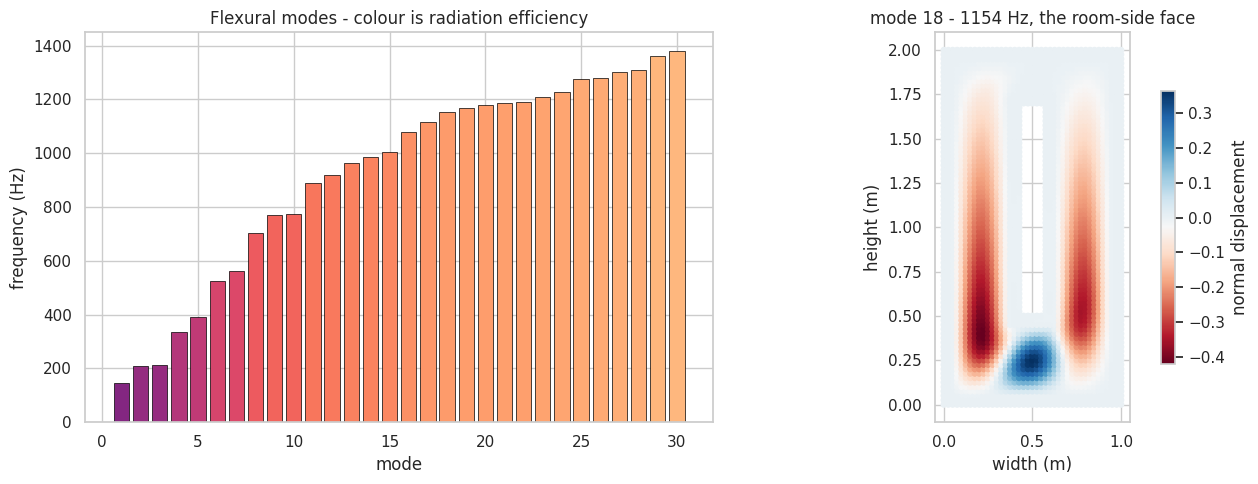

In [6]:
fem = solve_door_modes(CFG)

modes_tbl = Table(title="[bold medium_purple]Door flexural modes[/bold medium_purple]",
                  show_header=True, header_style="bold slate_blue1", show_lines=True)
modes_tbl.add_column("Mode", justify="right")
modes_tbl.add_column("Frequency (Hz)", justify="right")
modes_tbl.add_column("Radiation efficiency", justify="right")
for i in range(min(12, CFG.n_modes)):
    modes_tbl.add_row(str(i + 1), f"{fem.frequencies[i]:.0f}",
                      f"{fem.radiation_efficiency[i]:.3f}")
console.print(modes_tbl)

loud = int(np.argmax(np.abs(fem.volume_velocity)))
back = np.isclose(fem.nodes[:, 2], CFG.leaf_depth)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.bar(np.arange(1, CFG.n_modes + 1), fem.frequencies,
       color=plt.cm.magma(0.15 + 0.7 * fem.radiation_efficiency
                          / fem.radiation_efficiency.max()),
       edgecolor="black", lw=0.5)
ax.set_xlabel("mode")
ax.set_ylabel("frequency (Hz)")
ax.set_title("Flexural modes - colour is radiation efficiency")

ax = axes[1]
sc = ax.scatter(fem.nodes[back, 0], fem.nodes[back, 1],
                c=fem.shapes[loud][back, 2], cmap="RdBu", s=14)
ax.set_aspect("equal")
ax.set_xlabel("width (m)")
ax.set_ylabel("height (m)")
ax.set_title(f"mode {loud + 1} - {fem.frequencies[loud]:.0f} Hz, the room-side face")
fig.colorbar(sc, ax=ax, label="normal displacement", shrink=0.7)
fig.tight_layout()
fig.savefig(FIG_DIR / "04-door-modes.png", dpi=140, bbox_inches="tight")
plt.show()


## The Impact

The door is struck by the actual body-door contact force, not a guessed pulse. Notebook 02's 5-DOF posterior-thorax impact gives the contact-force history of the body striking the door; notebook 03's uneven-surface texture grains it - the ribs and spine engaging the steel bump by bump. That force, applied at the strike point on the front skin, projects onto each flexural mode and drives a damped modal oscillator. The steel rings on well after the contact ends, settled by the modal damping - that ring is the clang.


contact force peak 8.8 kN over 81 ms; the door rings for 600 ms of output.

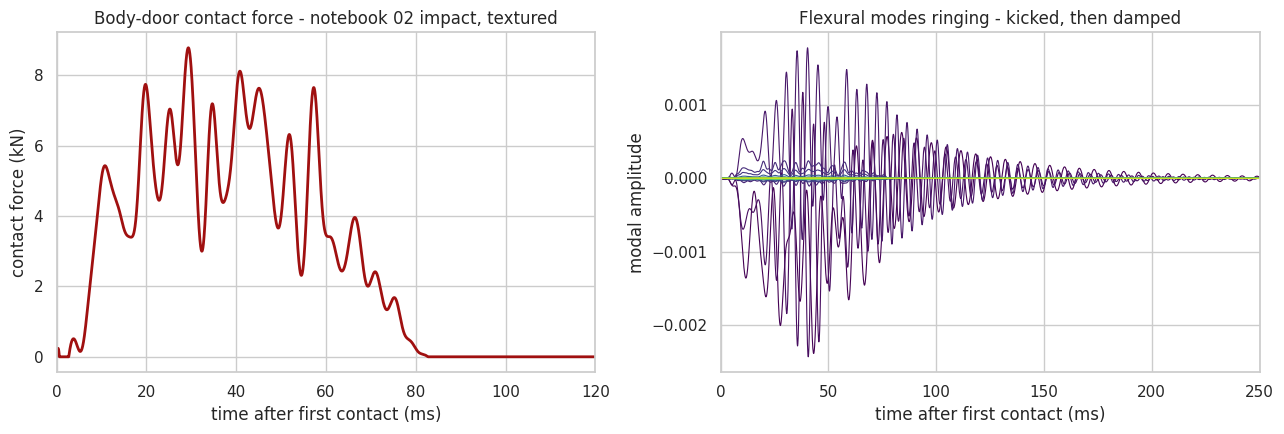

In [7]:
t, modal_q, modal_a, force = impact_response(fem, CFG)

contact = t[force > 0.01 * force.max()]
console.print(
    f"contact force peak [white]{force.max() / 1e3:.1f} kN[/white] over "
    f"[white]{(contact.max() - contact.min()) * 1e3:.0f} ms[/white]; the door rings for "
    f"[white]{CFG.t_max * 1e3:.0f} ms[/white] of output."
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(t * 1e3, force / 1e3, color="#a01010", lw=2)
ax.set_xlabel("time after first contact (ms)")
ax.set_ylabel("contact force (kN)")
ax.set_xlim(0, 120)
ax.set_title("Body-door contact force - notebook 02 impact, textured")

ax = axes[1]
cols = plt.cm.viridis(np.linspace(0, 0.92, CFG.n_modes))
for i in range(CFG.n_modes):
    ax.plot(t * 1e3, modal_q[i], color=cols[i], lw=0.8)
ax.set_xlabel("time after first contact (ms)")
ax.set_ylabel("modal amplitude")
ax.set_xlim(0, 250)
ax.set_title("Flexural modes ringing - kicked, then damped")
fig.tight_layout()
fig.savefig(FIG_DIR / "04-door-impact.png", dpi=140, bbox_inches="tight")
plt.show()


## The Clang

The room-side skin pushes air; the pushed air is the clang. The waveform is a brief metallic ring at the door's flexural frequencies, decaying as the modal damping bleeds the energy away. The spectrum carries the door's mode band - hundreds of hertz - far higher than the body's tens-of-hertz thump. The dB ratings are flat (peak SPL) and A-weighted (dBA); the combined waveform is written to a WAV file with a lead-in and a loudness lift for listening.


Door clang at the 1 m microphone: peak SPL 120.2 dB   A-weighted peak 107.5 dBA

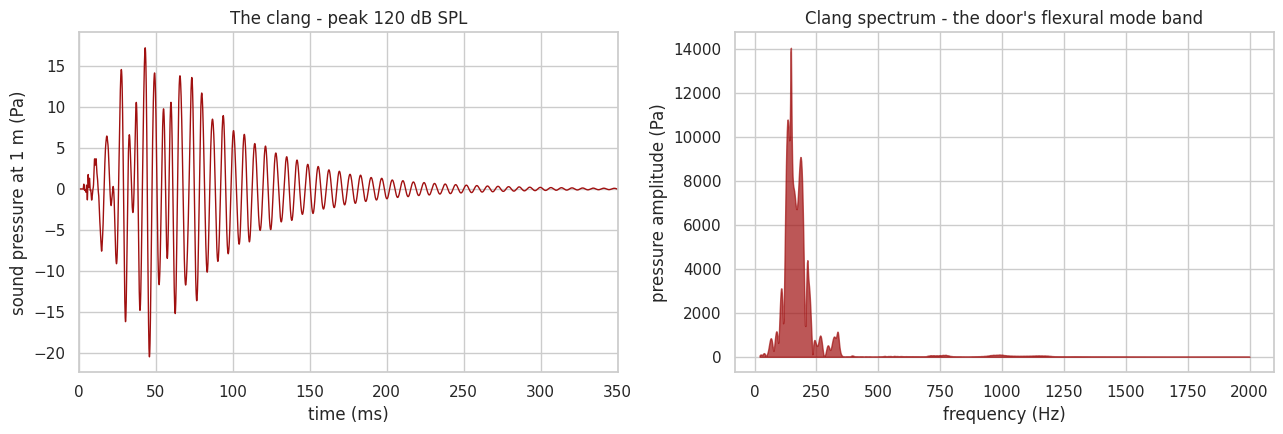

In [8]:
pressure = radiate(fem, t, modal_a, CFG)
fs = CFG.sample_rate
levels = sound_levels(pressure, fs)
console.print(
    f"[bold]Door clang at the 1 m microphone[/bold]: peak SPL "
    f"[white]{levels['peak_spl']:.1f} dB[/white]   "
    f"A-weighted peak [white]{levels['peak_dba']:.1f} dBA[/white]"
)

spec = np.abs(np.fft.rfft(pressure))
freq = np.fft.rfftfreq(len(pressure), 1.0 / fs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(t * 1e3, pressure, color="#a01010", lw=1.0)
ax.set_xlabel("time (ms)")
ax.set_ylabel("sound pressure at 1 m (Pa)")
ax.set_xlim(0, 350)
ax.set_title(f"The clang - peak {levels['peak_spl']:.0f} dB SPL")

ax = axes[1]
band = (freq >= 20.0) & (freq <= 2000.0)
ax.fill_between(freq[band], spec[band], color="#a01010", alpha=0.7)
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("pressure amplitude (Pa)")
ax.set_title("Clang spectrum - the door's flexural mode band")
fig.tight_layout()
fig.savefig(FIG_DIR / "04-door-clang.png", dpi=140, bbox_inches="tight")
plt.show()

## Corridor Propagation and Reflections

The microphone signal above is the direct path only. In the real corridor - a 2 m wide space with the E and W end walls about 10 m apart - the clang also reflects off the four walls. An image-source model of that corridor builds a reflection impulse response - the closely spaced side walls give the characteristic flutter echo - and the dry signal is filtered through it, adding the reflections and the reverberant tail. The corridor-filtered clang is what is written to the WAV.

corridor impulse response: 357 ms, 625 image sources, RT60 444 ms

dry peak SPL 120.2 dB  ->  corridor peak SPL 119.5 dB, A-weighted 106.8 dBA

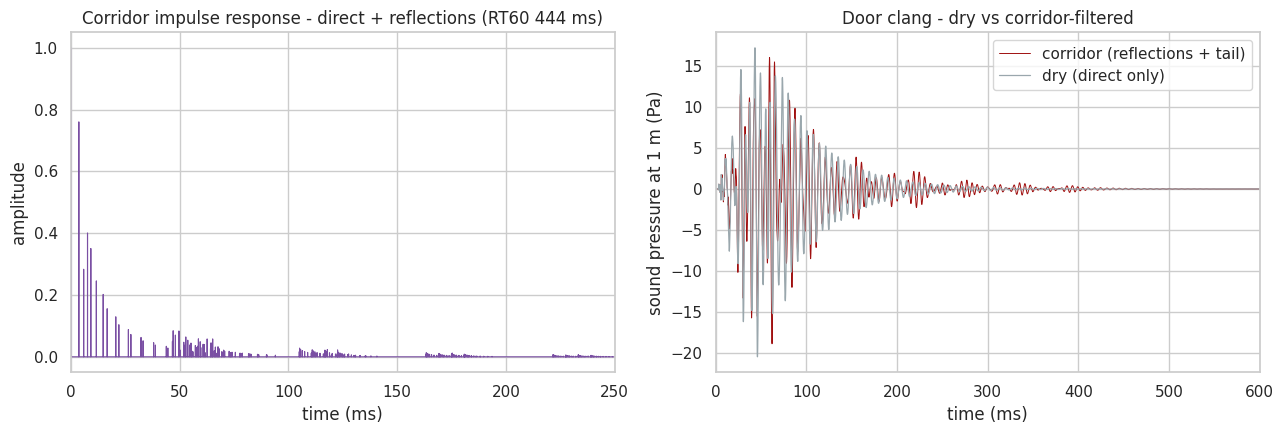

corridor-filtered audio written to ../reports/figures/04-door-clang.wav

In [9]:
# the dry 1 m signal filtered through the corridor's reflections
cir = corridor_impulse_response(REVERB)
pressure_corridor = apply_corridor_reverb(pressure, REVERB)
fs = CFG.sample_rate

lv_cor = sound_levels(pressure_corridor, fs)
console.print(
    f"corridor impulse response: [white]{len(cir.ir) / fs * 1e3:.0f} ms[/white], "
    f"[white]{cir.n_images}[/white] image sources, "
    f"RT60 [white]{cir.rt60 * 1e3:.0f} ms[/white]"
)
console.print(
    f"[bold]dry[/bold] peak SPL [white]{levels['peak_spl']:.1f} dB[/white]  ->  "
    f"[bold]corridor[/bold] peak SPL [white]{lv_cor['peak_spl']:.1f} dB[/white], "
    f"A-weighted [white]{lv_cor['peak_dba']:.1f} dBA[/white]"
)

t_ir = np.arange(len(cir.ir)) / fs * 1e3
t_dry = np.arange(len(pressure)) / fs * 1e3
t_cor = np.arange(len(pressure_corridor)) / fs * 1e3

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(t_ir, cir.ir, color="#7a4fa3", lw=0.8)
ax.set_xlabel("time (ms)")
ax.set_ylabel("amplitude")
ax.set_xlim(0, 250)
ax.set_title(f"Corridor impulse response - direct + reflections (RT60 {cir.rt60 * 1e3:.0f} ms)")
ax = axes[1]
ax.plot(t_cor, pressure_corridor, color="#a01010", lw=0.7,
        label="corridor (reflections + tail)")
ax.plot(t_dry, pressure, color="#9aa7ad", lw=0.9, label="dry (direct only)")
ax.set_xlabel("time (ms)")
ax.set_ylabel("sound pressure at 1 m (Pa)")
ax.set_xlim(0, 600)
ax.set_title("Door clang - dry vs corridor-filtered")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "04-corridor-reflections.png", dpi=140, bbox_inches="tight")
plt.show()

# WAV - the corridor-filtered sound, 0.5 s lead-in, loudness lift for listening
lead = np.zeros(int(0.5 * fs))
sound = np.concatenate([lead, pressure_corridor])
shaped = np.tanh(3.0 * sound / np.abs(sound).max())
shaped = shaped / np.abs(shaped).max() * 0.97
wav_path = FIG_DIR / "04-door-clang.wav"
wavfile.write(str(wav_path), fs, (shaped * 32767).astype(np.int16))
console.print(f"corridor-filtered audio written to [cyan]{wav_path}[/cyan]")

## Scenario Comparison - With and Without Free Coasting

Notebook 01's kinematics does not give a single closing velocity but an envelope. The body is either propelled the whole way to the door (no free coasting, the faster bound) or released early and left to coast the last stretch (with free coasting, the slower bound). The contact force scales with the closing velocity, so the door clang is run through the full FEM model at both bounds. The dB ratings are flat peak SPL and A-weighted (dBA).

In [10]:
# the closing-velocity envelope from notebook 01's kinematics
_no_coast, _with_coast = solve_envelope(ChoreographyConfig())

# the no-coast clang is the `pressure` solved above; solve the with-coast clang
res_coast = solve_door_sound(DoorFEMConfig(v_close=_with_coast.v_close))
scenarios = [
    ("Without free coasting", _no_coast.v_close, pressure),
    ("With free coasting", _with_coast.v_close, res_coast.pressure),
]

cmp_tbl = Table(title="Door clang - sound level by kinematics scenario",
                header_style="bold", show_lines=True)
cmp_tbl.add_column("scenario", style="bold medium_purple")
cmp_tbl.add_column("closing velocity", justify="right")
cmp_tbl.add_column("peak SPL", justify="right")
cmp_tbl.add_column("A-weighted", justify="right")
for name, v, sig in scenarios:
    lv = sound_levels(sig, CFG.sample_rate)
    cmp_tbl.add_row(name, f"{v:.2f} m/s",
                    f"{lv['peak_spl']:.1f} dB", f"{lv['peak_dba']:.1f} dBA")
console.print(cmp_tbl)

Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


          Door clang - sound level by kinematics scenario           
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ scenario              ┃ closing velocity ┃ peak SPL ┃ A-weighted ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━┩
│ Without free coasting │         2.74 m/s │ 120.2 dB │  107.5 dBA │
├───────────────────────┼──────────────────┼──────────┼────────────┤
│ With free coasting    │         2.35 m/s │ 118.7 dB │  105.4 dBA │
└───────────────────────┴──────────────────┴──────────┴────────────┘

## Summary

- The FEM door-impact sound model lives in `henryk_simulations.corridor.doorfem` - a library module under the corridor submodule. This notebook is a thin client over its staged functions.
- The radiating body is the **actual ZREMB DT37/1 door box** - two steel skins, the welded perimeter frame, the wired-glass window as a cutout - tessellated into a tetrahedral solid.
- A 3D linear-elastic finite-element model (scikit-fem) gives the leaf's flexural modes. The welded box is stiff; that is what makes the door clang rather than boom - a bare flat sheet would be far floppier.
- The body-door contact force - taken from notebook 02's 5-DOF impact and grained by notebook 03's surface texture - excites the modes at the strike point; modal damping settles the ring.
- The room-side skin radiates as a baffled panel. Every door mode is below the steel coincidence frequency, so it radiates sub-critically, with efficiency below one.
- The door clang is run at both ends of notebook 01's closing-velocity envelope. Without free coasting (2.74 m/s) it peaks at about **120 dB** SPL and **108 dBA**; with free coasting (2.35 m/s) about **119 dB** and **105 dBA** - a brief metallic clang in the door's mode band, distinct from and louder than the body's low thump.
- The 1 m microphone signal is the direct path only; a corridor-reflection post-processing filter (`reverb.py` - an image-source model of the 2 m x 10 m corridor, the E and W end walls about 10 m apart) adds the wall reflections and the reverberant tail (RT60 about 0.44 s). The corridor-filtered clang is the WAV that is written.